# FeatureCNN1D（一维卷积网络）

一维卷积网络将 30 个表格特征视作一维序列，通过 Conv1d 提取局部特征组合，作为区别于全连接网络的神经网络方法。

本 Notebook 是 2.3 乳腺癌良恶性分类实验的单模型实现。实验使用 PyTorch 完成；数据清洗、分层划分、标准化、指标计算和模型训练逻辑来自同目录下的 `breast_cancer_core.py`。

In [1]:
from pathlib import Path
import pandas as pd
import torch
from IPython.display import Image, display

from breast_cancer_core import (
    FEATURE_COLUMNS,
    MODEL_BUILDERS,
    classification_metrics,
    get_project_root,
    prepare_split,
    predict_features,
    roc_curve_points,
    save_preprocess_stats,
    set_seed,
    train_one_model,
)

pd.set_option('display.max_columns', 40)
seed = 42
set_seed(seed)
project_root = get_project_root()
data_path = project_root / '数据集' / 'breast cancer.csv'
results_dir = project_root / 'results'
figure_dir = project_root / '结果图'
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Project root:', project_root)
print('Data path:', data_path)
print('PyTorch version:', torch.__version__)
print('Device:', device)

Project root: D:\桌面\机器学习大作业\一.大作业\2代码\2.3乳腺癌分类
Data path: D:\桌面\机器学习大作业\一.大作业\2代码\2.3乳腺癌分类\数据集\breast cancer.csv
PyTorch version: 2.5.1
Device: cpu


## 1. 数据读取与预处理

原始数据包含 569 条样本、33 个字段。训练前删除样本编号 `id` 和全空列 `Unnamed: 32`，将标签 `diagnosis` 映射为 `B=0`、`M=1`。数据按标签分层划分为训练集、验证集和测试集，并只使用训练集统计量完成标准化。

In [2]:
raw_df, cleaned_df, split_data = prepare_split(data_path=data_path, seed=seed)
save_preprocess_stats(split_data, results_dir / 'preprocess_stats.json')
print('Raw shape:', raw_df.shape)
print('Cleaned shape:', cleaned_df.shape)
print('Feature count:', len(FEATURE_COLUMNS))
print('Label counts:')
print(cleaned_df['diagnosis'].map({0: 'Benign', 1: 'Malignant'}).value_counts())
print('Train/Val/Test:', len(split_data.y_train), len(split_data.y_val), len(split_data.y_test))
raw_df.head()

Raw shape: (569, 33)
Cleaned shape: (569, 31)
Feature count: 30
Label counts:
diagnosis
Benign       357
Malignant    212
Name: count, dtype: int64
Train/Val/Test: 398 86 85


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,perimeter_se,area_se,smoothness_se,compactness_se,concavity_se,concave points_se,symmetry_se,fractal_dimension_se,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,0.4956,1.1560,3.445,27.23,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,0.7572,0.7813,5.438,94.44,0.011490,0.02461,0.05688,0.01885,0.01756,0.005115,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


## 2. 模型结构

下面构建当前 Notebook 对应的 PyTorch 模型。输入维度为 30，输出维度为 2，分别表示良性和恶性。

In [3]:
model_name = 'FeatureCNN1D'
model = MODEL_BUILDERS[model_name](input_dim=len(FEATURE_COLUMNS), num_classes=2)
print(model)

FeatureCNN1D(
  (features): Sequential(
    (0): Conv1d(1, 16, kernel_size=(3,), stride=(1,), padding=(1,))
    (1): BatchNorm1d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv1d(16, 32, kernel_size=(3,), stride=(1,), padding=(1,))
    (4): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): AdaptiveAvgPool1d(output_size=1)
  )
  (classifier): Linear(in_features=32, out_features=2, bias=True)
)


## 3. 模型训练

训练使用交叉熵损失函数和 Adam 优化器，最大训练 300 轮。验证集 F1-score 不再提升时触发 early stopping，并保存验证集表现最好的模型参数。

In [4]:
result = train_one_model(
    model_name=model_name,
    model=model,
    split_data=split_data,
    output_dir=results_dir,
    device=device,
    batch_size=32,
    max_epochs=300,
    patience=30,
    lr=1e-3,
    weight_decay=1e-4,
)
print('Best epoch:', result['best_epoch'])
print('Checkpoint:', result['checkpoint_path'])

Best epoch: 152
Checkpoint: D:\桌面\机器学习大作业\一.大作业\2代码\2.3乳腺癌分类\results\FeatureCNN1D.pt


## 4. 训练过程可视化

训练历史记录包含训练损失、训练 F1、验证损失和验证 F1。通过曲线可以观察模型是否收敛，以及是否出现过拟合趋势。

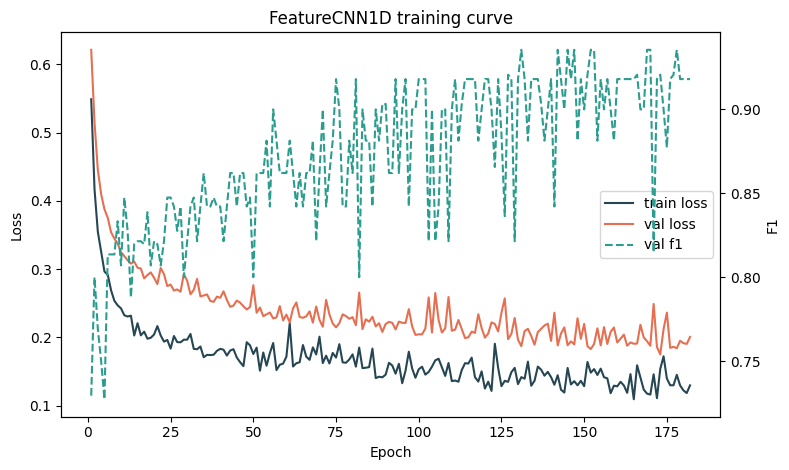

,epoch,train_loss,train_accuracy,train_f1,val_loss,val_accuracy,val_f1
177,178,0.145004,0.964824,0.952381,0.183903,0.953488,0.935484
178,179,0.129486,0.964824,0.952055,0.194989,0.941860,0.918033
179,180,0.122232,0.967337,0.955326,0.191452,0.941860,0.918033
180,181,0.118290,0.962312,0.948805,0.190312,0.941860,0.918033
181,182,0.129558,0.964824,0.951724,0.200541,0.941860,0.918033


In [5]:
import matplotlib.pyplot as plt

history = pd.DataFrame(result['history'])
fig, ax1 = plt.subplots(figsize=(8, 4.8))
ax1.plot(history['epoch'], history['train_loss'], label='train loss', color='#264653')
ax1.plot(history['epoch'], history['val_loss'], label='val loss', color='#E76F51')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax2 = ax1.twinx()
ax2.plot(history['epoch'], history['val_f1'], label='val f1', color='#2A9D8F', linestyle='--')
ax2.set_ylabel('F1')
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='center right')
plt.title(f'{model_name} training curve')
plt.tight_layout()
plt.show()
history.tail()

## 5. 测试集评价

测试集指标包括 Accuracy、Precision、Recall、Specificity、F1-score、ROC-AUC 和混淆矩阵。恶性样本作为正类。

In [6]:
metrics = result['test_metrics']
metrics_df = pd.DataFrame([{
    'model': model_name,
    'accuracy': metrics['accuracy'],
    'precision': metrics['precision'],
    'recall': metrics['recall'],
    'specificity': metrics['specificity'],
    'f1': metrics['f1'],
    'roc_auc': metrics['roc_auc'],
    'tn': metrics['tn'],
    'fp': metrics['fp'],
    'fn': metrics['fn'],
    'tp': metrics['tp'],
}])
metrics_df

,model,accuracy,precision,recall,specificity,f1,roc_auc,tn,fp,fn,tp
0,FeatureCNN1D,0.952941,0.9375,0.9375,0.962264,0.9375,0.990566,51,2,2,30


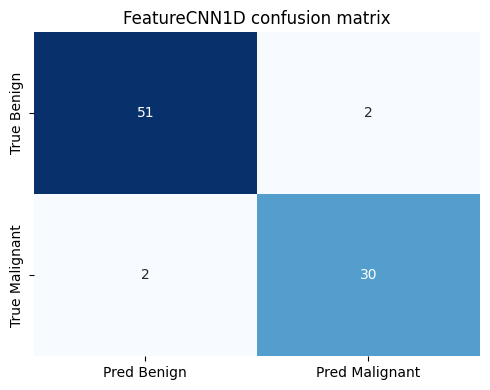

In [7]:
import numpy as np
import seaborn as sns

matrix = np.array([[metrics['tn'], metrics['fp']], [metrics['fn'], metrics['tp']]])
plt.figure(figsize=(5, 4))
sns.heatmap(
    matrix,
    annot=True,
    fmt='d',
    cmap='Blues',
    cbar=False,
    xticklabels=['Pred Benign', 'Pred Malignant'],
    yticklabels=['True Benign', 'True Malignant'],
)
plt.title(f'{model_name} confusion matrix')
plt.tight_layout()
plt.show()

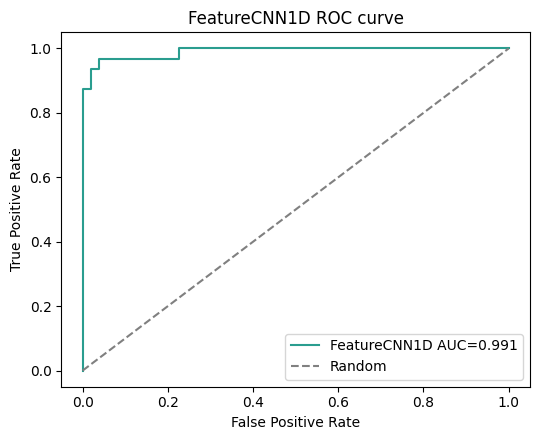

In [8]:
logits = result['test_logits']
probabilities = torch.softmax(logits, dim=1)[:, 1]
fpr, tpr = roc_curve_points(split_data.y_test, probabilities)
plt.figure(figsize=(5.5, 4.5))
plt.plot(fpr, tpr, label=f'{model_name} AUC={metrics["roc_auc"]:.3f}', color='#2A9D8F')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title(f'{model_name} ROC curve')
plt.legend()
plt.tight_layout()
plt.show()

## 6. 单样本预测

下面选取数据集中第 0 行样本进行预测，展示模型输出的良性概率和恶性概率。

In [9]:
sample = raw_df.iloc[0]
features = [float(sample[col]) for col in FEATURE_COLUMNS]
prediction = predict_features(
    features,
    model_path=results_dir / f'{model_name}.pt',
    stats_path=results_dir / 'preprocess_stats.json',
)
print('True label:', '恶性' if sample['diagnosis'] == 'M' else '良性')
prediction

True label: 恶性


{'prediction': 1,
 'prediction_en': 'Malignant',
 'prediction_zh': '恶性',
 'benign_probability': 0.002387452404946089,
 'malignant_probability': 0.9976125955581665}

## 7. 小结

本模型完成了从数据读取、预处理、训练、评价到单样本预测的完整流程。最终模型对比见总览 Notebook `breast_cancer_pytorch.ipynb`。